# 000978 stage 6b — session-sequence alignment (learning trajectory)

From `src/000978/06b_session_sequence.py`. For each of the 7 clean single-day
animals (ZT2 excluded — two separate days), each run session's manifold is
aligned to the **final** session via position-binned Procrustes/CCA. A falling
disparity across sessions = the map converging as the animal learns.

**CEBRA is behavior-aligned** (position baked in) so it looks converged from the
start; the **unsupervised** UMAP/Isomap embeddings give the honest signal.


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000978")
BIN_MS = int(BIN_SIZE_S * 1000)
METHODS = ["umap", "isomap", "cebra"]
REGION_COLOR = {"CA1": "tab:blue", "PFC": "tab:red"}
plt.rcParams["figure.dpi"] = 100

## Load results

In [2]:
frames = []
for m in METHODS:
    f = DATA_PROCESSED / f"stage6b_session_sequence_{m}_{BIN_MS}ms.csv"
    if f.exists(): frames.append(pd.read_csv(f))
df = pd.concat(frames, ignore_index=True)
print("animals:", sorted(df.session_key.unique()))
print("rows:", len(df))
df.groupby(["method"]).apply(lambda g: g[g.session <= 2].procrustes_disparity.mean()
                             - g[g.session >= 6].procrustes_disparity.mean()).round(3).rename("early-late drop")

animals: ['ER1', 'JS14', 'JS15', 'JS17', 'JS21', 'JS34', 'KL8']
rows: 336


method
cebra     0.029
isomap    0.257
umap      0.280
Name: early-late drop, dtype: float64

## 1. Convergence to the final session

Mean Procrustes disparity-to-final vs. run session (± sem across animals), split
by region. Thin lines are individual animals (unsupervised methods). A downward
trend = learning-related convergence.

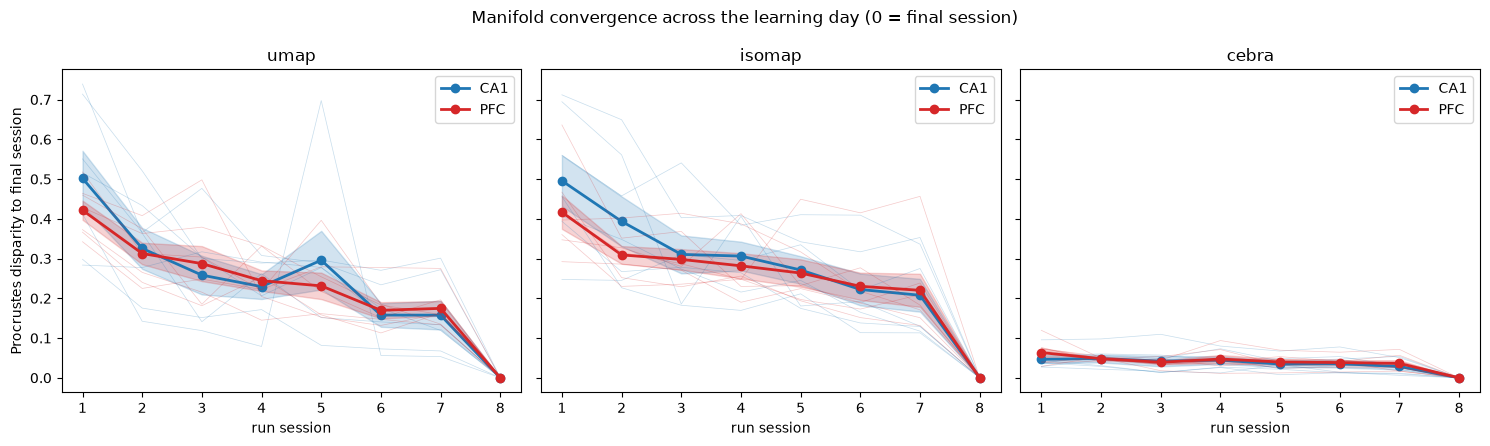

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, method in zip(axes, METHODS):
    sub = df[df.method == method]
    for region in ["CA1", "PFC"]:
        r = sub[sub.region == region]
        for key, g in r.groupby("session_key"):
            g = g.sort_values("session")
            ax.plot(g.session, g.procrustes_disparity, color=REGION_COLOR[region], lw=0.5, alpha=0.25)
        m = r.groupby("session")["procrustes_disparity"].agg(["mean", "sem"])
        ax.plot(m.index, m["mean"], "-o", color=REGION_COLOR[region], label=region, lw=2)
        ax.fill_between(m.index, m["mean"] - m["sem"], m["mean"] + m["sem"],
                        color=REGION_COLOR[region], alpha=0.2)
    ax.set_title(method); ax.set_xlabel("run session")
    ax.legend()
axes[0].set_ylabel("Procrustes disparity to final session")
fig.suptitle("Manifold convergence across the learning day (0 = final session)")
plt.tight_layout()

## 2. CCA correlation to the final session
Higher = more similar; should rise toward the final session.

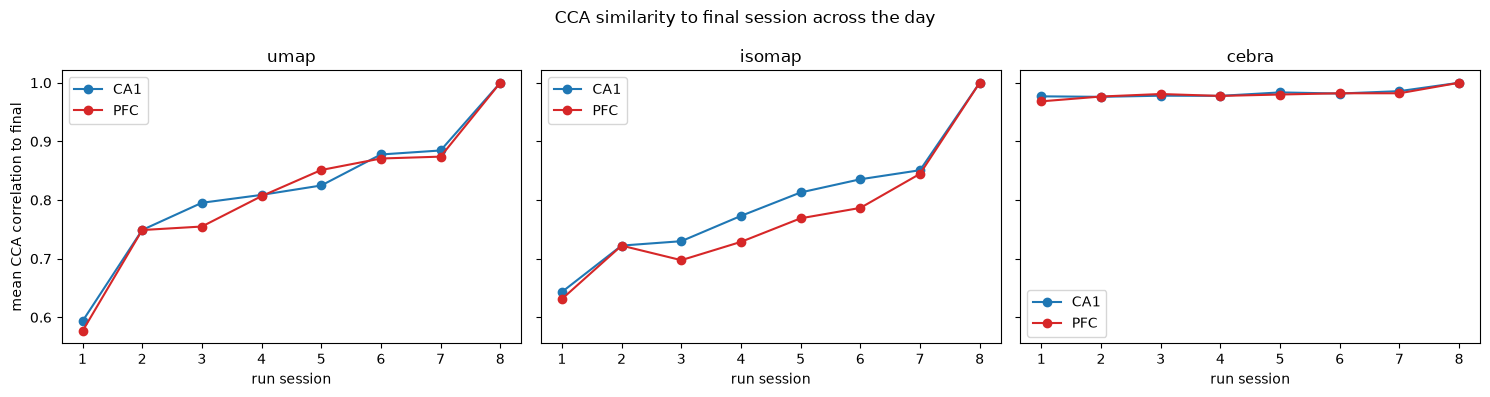

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, method in zip(axes, METHODS):
    sub = df[df.method == method]
    for region in ["CA1", "PFC"]:
        m = sub[sub.region == region].groupby("session")["cca_mean_r"].mean()
        ax.plot(m.index, m.values, "-o", color=REGION_COLOR[region], label=region)
    ax.set_title(method); ax.set_xlabel("run session"); ax.legend()
axes[0].set_ylabel("mean CCA correlation to final")
fig.suptitle("CCA similarity to final session across the day")
plt.tight_layout()

## 3. Early vs. late, per animal (UMAP)

Disparity-to-final for early (sessions 1-2) vs. late (6-7) run sessions. Points
below the diagonal converged toward the final map.

mean early: 0.39 mean late: 0.165


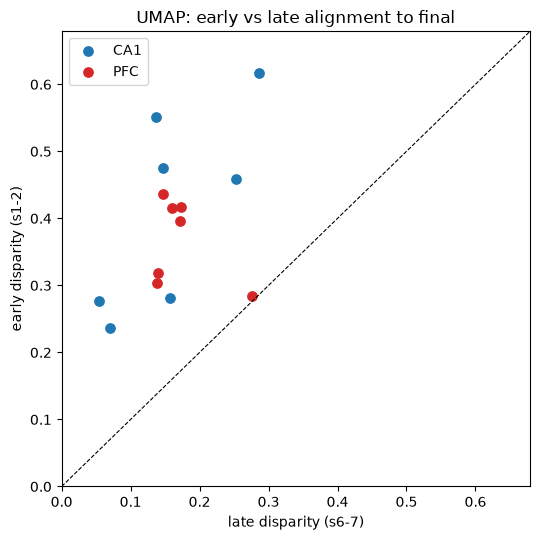

In [5]:
u = df[df.method == "umap"]
early = u[u.session <= 2].groupby(["session_key", "region"]).procrustes_disparity.mean()
late = u[u.session.between(6, 7)].groupby(["session_key", "region"]).procrustes_disparity.mean()
comp = pd.DataFrame({"early": early, "late": late}).dropna().reset_index()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for region in ["CA1", "PFC"]:
    r = comp[comp.region == region]
    ax.scatter(r.late, r.early, color=REGION_COLOR[region], s=45, label=region)
lim = [0, comp[["early", "late"]].values.max() * 1.1]
ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("late disparity (s6-7)"); ax.set_ylabel("early disparity (s1-2)")
ax.set_title("UMAP: early vs late alignment to final"); ax.legend()
plt.tight_layout()
print("mean early:", round(comp.early.mean(), 3), "mean late:", round(comp.late.mean(), 3))

## 4. Embedding robustness — convergence at 50 ms (linearized), CEBRA vs. UMAP

Learning convergence should not depend on the embedding. Disparity-to-final vs.
run session on the **linearized** track (50 ms), for UMAP, unsupervised
CEBRA-Time, and supervised CEBRA. All three fall monotonically; CEBRA-Time
(≈0.45→0.15) tracks UMAP (≈0.39→0.13), while supervised CEBRA is compressed
(≈0.17→0.06) but same direction.

,method,early(<=2),late(>=6)
0,UMAP (unsup),0.388,0.129
1,CEBRA-Time (unsup),0.448,0.146
2,CEBRA (sup),0.174,0.058


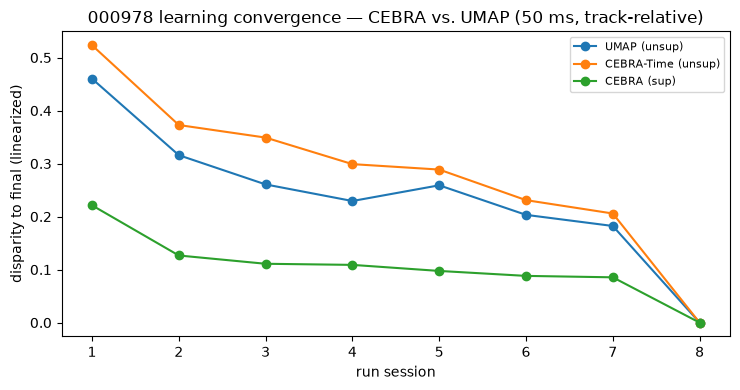

In [6]:
# CEBRA vs. UMAP — 000978 learning convergence at 50 ms, LINEARIZED (track-relative)
methods50 = ["umap", "cebratime", "cebra"]
mlab = {"umap": "UMAP (unsup)", "cebratime": "CEBRA-Time (unsup)", "cebra": "CEBRA (sup)"}
fig, ax = plt.subplots(figsize=(7.5, 4)); summ = []
for m in methods50:
    f = DATA_PROCESSED / f"stage6b_linearized_{m}.csv"
    if not f.exists():
        continue
    d = pd.read_csv(f)
    per = d.groupby("session").disparity.mean()
    ax.plot(per.index, per.values, "-o", label=mlab[m])
    summ.append((mlab[m], d[d.session <= 2].disparity.mean(), d[d.session >= 6].disparity.mean()))
ax.set_xlabel("run session"); ax.set_ylabel("disparity to final (linearized)")
ax.set_title("000978 learning convergence — CEBRA vs. UMAP (50 ms, track-relative)")
ax.legend(fontsize=8); plt.tight_layout()
pd.DataFrame(summ, columns=["method", "early(<=2)", "late(>=6)"]).round(3)

---
**Result:** unsupervised embeddings show the manifold's disparity to the final
session **falls across the day** — the population geometry converges as the
animal learns the W-track, the geometric signature the 000978 study targets.
CEBRA is flat (position baked in). **Next:** 6c — project sleep epochs into the
awake manifold to test for replay of the learned geometry.